In [2]:
# Load the cleaned dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/cleaned_mnch_data.csv')
df['Period'] = pd.to_datetime(df['Period'])

print(df.shape)

(1140, 19)


  Stage   Total  Pct_of_ANC1  Drop_From_Previous_Pct
0  ANC1  326712   100.000000                     NaN
1  ANC4  197393    60.418044                   -39.6
2   SBA  182244    55.781239                    -7.7
3   PNC  181137    55.442408                    -0.6
4   FIC  168355    51.530094                    -7.1


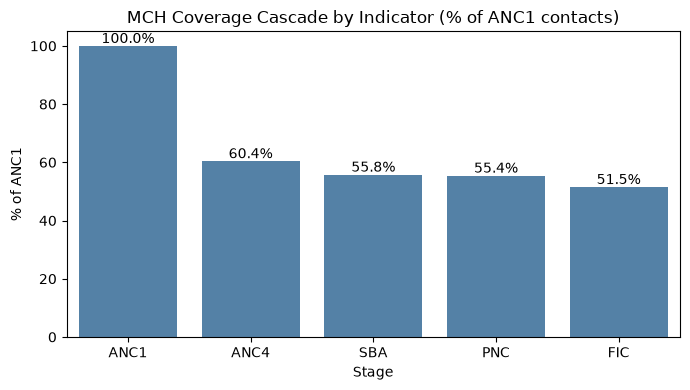

In [3]:
# Finding 1: Cascade Leak

total_anc1 = df['ANC_1st_Visits'].sum()
total_anc4 = df['ANC_4th_Visits'].sum()
total_sba = df['Deliveries_Skilled_Attendant'].sum()
total_pnc = df['PNC_Visits_Within_48hrs'].sum()
total_fic = df['Fully_Immunized_Children_FIC'].sum()

cascade = pd.DataFrame({
    'Stage': ['ANC1', 'ANC4', 'SBA', 'PNC', 'FIC'],
    'Total': [total_anc1, total_anc4, total_sba, total_pnc, total_fic]
})
cascade['Pct_of_ANC1'] = (cascade['Total'] / total_anc1) * 100
cascade['Drop_From_Previous_Pct'] = cascade['Total'].pct_change().mul(100).round(1)

print(cascade)

plt.figure(figsize=(7, 4))
sns.barplot(data=cascade, x='Stage', y='Pct_of_ANC1', color='steelblue')
plt.ylabel('% of ANC1')
plt.title('MCH Coverage Cascade by Indicator (% of ANC1 contacts)')
for i, v in enumerate(cascade['Pct_of_ANC1']):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.tight_layout()
plt.savefig('finding1_cascade.png', dpi=150)
plt.show()

cascade.to_csv('findings/finding1_cascade_summary.csv', index=False)

County_Type  Other  Rain-Sensitive
Period                            
2025-01-01    92.4            91.6
2025-02-01    91.8            93.5
2025-03-01    92.9            92.9
2025-04-01    90.7            71.2
2025-05-01    92.5            73.7
2025-06-01    91.4            92.9
2025-07-01    92.5            91.4
2025-08-01    94.0            92.2
2025-09-01    92.8            92.2
2025-10-01    92.8            71.6
2025-11-01    90.1            73.2
2025-12-01    90.2            90.1


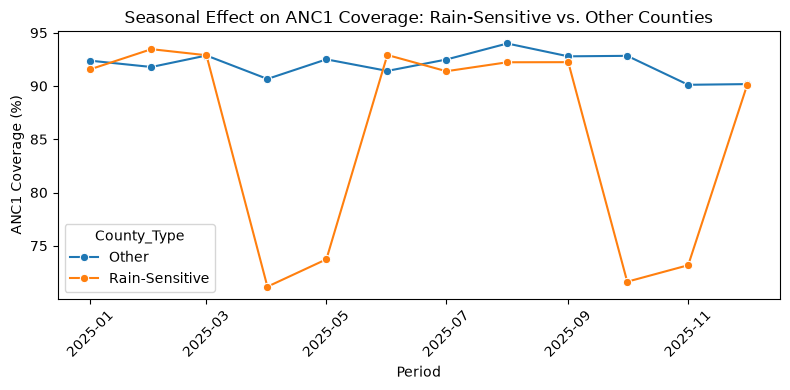

In [4]:
# Finding 2: Seasonality

rain_sensitive = ['Turkana', 'Homa Bay', 'Kilifi']
df['County_Type'] = np.where(df['County'].isin(rain_sensitive), 'Rain-Sensitive', 'Other')

seasonal = df.groupby(['Period', 'County_Type']).apply(
    lambda g: (g['ANC_1st_Visits'].sum() / g['Target_Population_Pregnant'].sum()) * 100,
    include_groups=False
).reset_index(name='ANC1_Coverage_Pct')

seasonal_pivot = seasonal.pivot(index='Period', columns='County_Type', values='ANC1_Coverage_Pct')
print(seasonal_pivot.round(1))

plt.figure(figsize=(8, 4))
sns.lineplot(data=seasonal, x='Period', y='ANC1_Coverage_Pct', hue='County_Type', marker='o')
plt.ylabel('ANC1 Coverage (%)')
plt.title('Seasonal Effect on ANC1 Coverage: Rain-Sensitive vs. Other Counties')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('finding2_seasonality.png', dpi=150)
plt.show()

seasonal_pivot.reset_index().to_csv('findings/finding2_seasonality_summary.csv', index=False)

Correlation between PNC-flag frequency (quality) and Avg Attrition: 0.061
                         mean  count
Chronic_Status                      
Chronic (3+ months)      39.6     18
Clean (0 months)         38.9     14
Occasional (1-2 months)  39.3     68


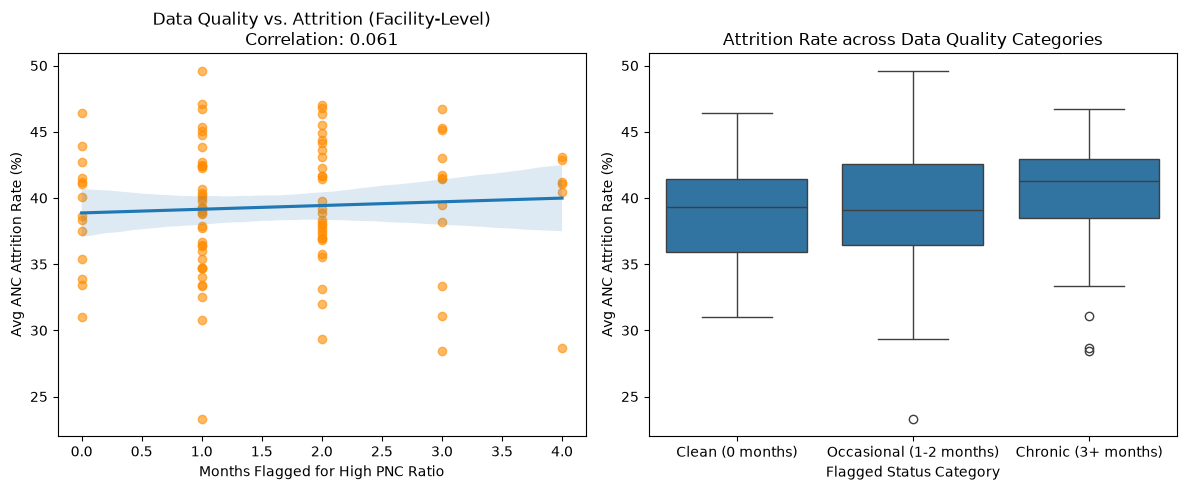

In [5]:
# Finding 3: Data Quality vs. Attrition

facility_level = df.groupby('Facility_ID').agg(
    County=('County', 'first'),
    Facility_Level=('Facility_Level', 'first'),
    Avg_Attrition=('ANC_Attrition_Rate_Pct', 'mean'),
    PNC_Flag_Months=('Warning_High_PNC_Ratio', 'sum')
).reset_index()

corr = facility_level['PNC_Flag_Months'].corr(facility_level['Avg_Attrition'])
print(f"Correlation between PNC-flag frequency (quality) and Avg Attrition: {corr:.3f}")

facility_level['Chronic_Status'] = np.where(
    facility_level['PNC_Flag_Months'] >= 3, 'Chronic (3+ months)',
    np.where(facility_level['PNC_Flag_Months'] >= 1, 'Occasional (1-2 months)', 'Clean (0 months)')
)
print(facility_level.groupby('Chronic_Status')['Avg_Attrition'].agg(['mean', 'count']).round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.regplot(data=facility_level, x='PNC_Flag_Months', y='Avg_Attrition', ax=axes[0],
            scatter_kws={'alpha': 0.6, 'color': 'darkorange'})
axes[0].set_title(f'Data Quality vs. Attrition (Facility-Level)\nCorrelation: {corr:.3f}')
axes[0].set_xlabel('Months Flagged for High PNC Ratio')
axes[0].set_ylabel('Avg ANC Attrition Rate (%)')

sns.boxplot(data=facility_level, x='Chronic_Status', y='Avg_Attrition',
            order=['Clean (0 months)', 'Occasional (1-2 months)', 'Chronic (3+ months)'], ax=axes[1])
axes[1].set_title('Attrition Rate across Data Quality Categories')
axes[1].set_xlabel('Flagged Status Category')
axes[1].set_ylabel('Avg ANC Attrition Rate (%)')

plt.tight_layout()
plt.savefig('finding3_dqi_vs_attrition.png', dpi=150)
plt.show()

facility_level.to_csv('findings/finding3_facility_summary.csv', index=False)